In [1]:
import pandas as pd
import numpy as np

In [2]:
# loading the dataset

df = pd.read_csv(r"C:\Users\User\Desktop\week 5\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
# copying dataset
df1 = df.copy()

In [12]:
# identifying columns with missing values

df1.columns.isna().sum()

np.int64(0)

In [14]:
# identifying columns with duplicate values

df1.duplicated().sum()

np.int64(0)

In [15]:
# ensuring consistency in dtype
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [17]:
df1["TotalCharges"] = pd.to_numeric(df1["TotalCharges"], errors="coerce")

In [18]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [20]:
df1.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [ ]:
df1[df1["TotalCharges"].isna () == True] 
# since the missing values is only 11 row out of 7043 i have decided to just let that be.

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [24]:
df1.select_dtypes(include = "str").columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')

In [31]:
# text standardization
text_columns = [ 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'] 

for col in text_columns:
    df1[col] = df1[col].str.strip().str.replace(r's+', ' ', regex= True).str.title()

In [ ]:
# Each column cleaning
df1["gender"].unique()

<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

In [ ]:
df1["Partner"].unique()

<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

In [ ]:
df1["Dependents"].unique()

<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

In [ ]:
df1["PhoneService"].unique()

<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

In [ ]:
df1['MultipleLines'].unique()

<ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

In [ ]:
df1['InternetService'].unique()

<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

In [ ]:
df1['OnlineSecurity'].unique()

<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [ ]:
df1['OnlineBackup'].unique()

<ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

In [ ]:
df1['DeviceProtection'].unique()

<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [ ]:
df1['TechSupport'].unique()

<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [ ]:
df1[ 'StreamingTV'].unique()

<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [ ]:
df1['StreamingMovies'].unique()

<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [ ]:
df1['Contract'].unique()

<ArrowStringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

In [ ]:
df1['PaperlessBilling'].unique()

<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

In [ ]:
df1['PaymentMethod'].unique()

<ArrowStringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

In [ ]:
df1['Churn'].unique()

<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

In [78]:
# fixing incosistency in the column names 

import re

df1.columns = (
    df1.columns
    .str.replace("customerID", "customer_id")
    .str.replace(r'(?<!^)(?=[A-Z])', '_', regex=True)
    .str.lower())

In [83]:
df1.columns = (
    df1.columns.str.replace("customer_i_d", "customer_id"))

In [84]:
df1.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_t_v', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='str')

In [87]:
# checking for invalid values

df1["senior_citizen"][df1["senior_citizen"] < 0].sum()

np.int64(0)

In [88]:
df1["tenure"][df1["tenure"]<0].sum()

np.int64(0)

In [91]:
df1['monthly_charges'][df1['monthly_charges']<=0].sum()

np.float64(0.0)

In [93]:
df1[ 'total_charges'][df1[ 'total_charges']<=0].sum()

np.float64(0.0)

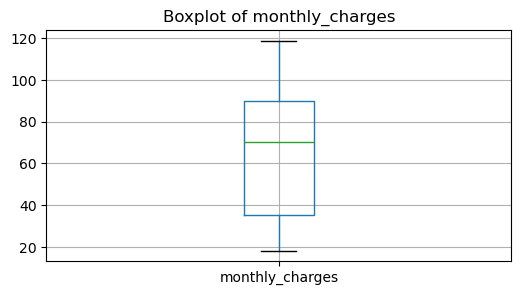

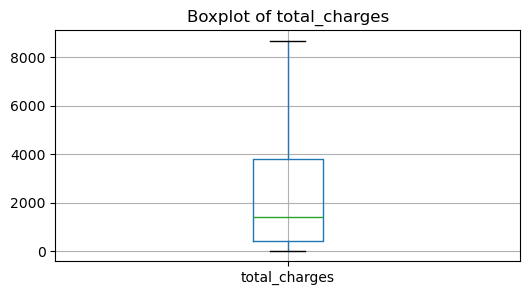

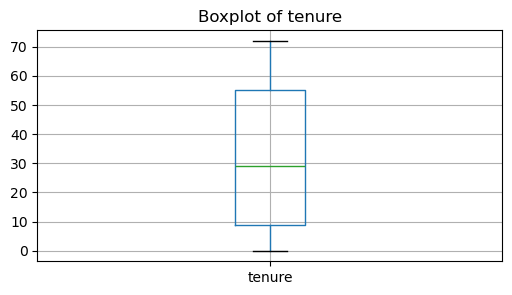

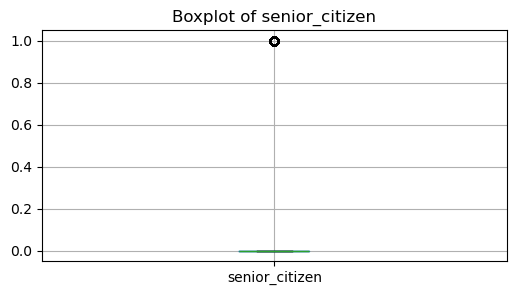

In [94]:
# Identifying Outliers 
import matplotlib.pyplot as plt

numeric_cols = ['monthly_charges', 'total_charges', "tenure","senior_citizen"]

for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    df1.boxplot(column=col)
    plt.title(f"Boxplot of {col}")
    plt.show()


In [105]:
# total charges

df1["total_charges"].sort_values(ascending = False).head(25)

4610    8684.80
4586    8672.45
6768    8670.10
5347    8594.40
2187    8564.75
6118    8547.15
5558    8543.25
2368    8529.50
2603    8496.70
2025    8477.70
2115    8477.60
850     8476.50
437     8468.20
4206    8456.75
4229    8443.70
4155    8436.25
2559    8425.30
3897    8425.15
4553    8424.90
2667    8405.00
464     8404.90
526     8399.15
1693    8375.05
6728    8349.70
4170    8349.45
Name: total_charges, dtype: float64

In [107]:
df1.to_csv("telco_customer_churn_cleaned.csv" , index = False)

|ISSUES FOUND | ACTION TAKEN|
|-----------------|-------------|
|1.The column `total_charges` was stored as a str instead of float64| used pd.to_numeric to covert the column to float64 coercing invalid values to NaN to handle inconsistent entries.|
|2. incosistency in column names| converted all column names to follow the snake_case and readability|
|3. The column `total_charges` had 11 missing values| left it like that because its less that 20% missing values|